<a href="https://colab.research.google.com/github/Abhilovescars/btc-price-pressure-ml/blob/main/LR_short_term_price_movement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


In [64]:
import requests
import zipfile
import io
import os

# Create data folder
os.makedirs("data", exist_ok=True)

# Binance historical aggregated trades (1 day)
url = "https://data.binance.vision/data/spot/daily/aggTrades/BTCUSDT/BTCUSDT-aggTrades-2023-01-01.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("data")

print("Download and extraction complete.")


Download and extraction complete.


In [65]:
df = pd.read_csv("data/BTCUSDT-aggTrades-2023-01-01.csv")
df.head()


,2054785120,16541.77000000,0.00257000,2408185868,2408185868.1,1672531200001,True,True.1
0,2054785121,16541.77,0.00177,2408185869,2408185869,1672531200007,True,True
1,2054785122,16541.77,0.05700,2408185870,2408185871,1672531200007,True,True
2,2054785123,16541.77,0.00073,2408185872,2408185872,1672531200008,True,True
3,2054785124,16542.40,0.00133,2408185873,2408185873,1672531200009,False,True
4,2054785125,16542.39,0.00678,2408185874,2408185874,1672531200010,False,True


In [66]:
df = pd.read_csv(
    "data/BTCUSDT-aggTrades-2023-01-01.csv",
    header=None
)

df.head()


,0,1,2,3,4,5,6,7
0,2054785120,16541.77,0.00257,2408185868,2408185868,1672531200001,True,True
1,2054785121,16541.77,0.00177,2408185869,2408185869,1672531200007,True,True
2,2054785122,16541.77,0.05700,2408185870,2408185871,1672531200007,True,True
3,2054785123,16541.77,0.00073,2408185872,2408185872,1672531200008,True,True
4,2054785124,16542.40,0.00133,2408185873,2408185873,1672531200009,False,True


In [67]:
df.columns = [
    "agg_trade_id",
    "price",
    "volume",
    "first_trade_id",
    "last_trade_id",
    "timestamp",
    "is_buyer_maker",
    "is_best_match"
]

df.head()


,agg_trade_id,price,volume,first_trade_id,last_trade_id,timestamp,is_buyer_maker,is_best_match
0,2054785120,16541.77,0.00257,2408185868,2408185868,1672531200001,True,True
1,2054785121,16541.77,0.00177,2408185869,2408185869,1672531200007,True,True
2,2054785122,16541.77,0.05700,2408185870,2408185871,1672531200007,True,True
3,2054785123,16541.77,0.00073,2408185872,2408185872,1672531200008,True,True
4,2054785124,16542.40,0.00133,2408185873,2408185873,1672531200009,False,True


In [68]:
df = df[["timestamp", "price", "volume"]]
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()



,timestamp,price,volume
0,1672531200001,16541.77,0.00257
1,1672531200007,16541.77,0.00177
2,1672531200007,16541.77,0.05700
3,1672531200008,16541.77,0.00073
4,1672531200009,16542.40,0.00133


In [69]:
#df.info()
#pd.to_datetime(1672531200001, unit="ms")
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
df.head()


,timestamp,price,volume,datetime
0,1672531200001,16541.77,0.00257,2023-01-01 00:00:00.001000+00:00
1,1672531200007,16541.77,0.00177,2023-01-01 00:00:00.007000+00:00
2,1672531200007,16541.77,0.05700,2023-01-01 00:00:00.007000+00:00
3,1672531200008,16541.77,0.00073,2023-01-01 00:00:00.008000+00:00
4,1672531200009,16542.40,0.00133,2023-01-01 00:00:00.009000+00:00


In [70]:
df["time_diff_ms"] = df["timestamp"].diff()
df.head()


,timestamp,price,volume,datetime,time_diff_ms
0,1672531200001,16541.77,0.00257,2023-01-01 00:00:00.001000+00:00,NaN
1,1672531200007,16541.77,0.00177,2023-01-01 00:00:00.007000+00:00,6.0
2,1672531200007,16541.77,0.05700,2023-01-01 00:00:00.007000+00:00,0.0
3,1672531200008,16541.77,0.00073,2023-01-01 00:00:00.008000+00:00,1.0
4,1672531200009,16542.40,0.00133,2023-01-01 00:00:00.009000+00:00,1.0


In [71]:
horizon = 10

df["future_price"] = df["price"].shift(-horizon)
df["price_change"] = df["future_price"] - df["price"]

df.head(15)


,timestamp,price,volume,datetime,time_diff_ms,future_price,price_change
0,1672531200001,16541.77,0.00257,2023-01-01 00:00:00.001000+00:00,NaN,16542.40,0.63
1,1672531200007,16541.77,0.00177,2023-01-01 00:00:00.007000+00:00,6.0,16542.39,0.62
2,1672531200007,16541.77,0.05700,2023-01-01 00:00:00.007000+00:00,0.0,16542.65,0.88
3,1672531200008,16541.77,0.00073,2023-01-01 00:00:00.008000+00:00,1.0,16542.69,0.92
4,1672531200009,16542.40,0.00133,2023-01-01 00:00:00.009000+00:00,1.0,16542.48,0.08
5,1672531200010,16542.41,0.01285,2023-01-01 00:00:00.010000+00:00,1.0,16542.72,0.31
6,1672531200010,16542.50,0.05138,2023-01-01 00:00:00.010000+00:00,0.0,16543.07,0.57
7,1672531200010,16542.49,0.10115,2023-01-01 00:00:00.010000+00:00,0.0,16543.06,0.57
8,1672531200010,16542.57,0.01300,2023-01-01 00:00:00.010000+00:00,0.0,16543.03,0.46
9,1672531200010,16542.63,0.03550,2023-01-01 00:00:00.010000+00:00,0.0,16543.20,0.57


In [72]:
lookback = 5

df["recent_price_change"] = df["price"] - df["price"].shift(lookback)
df["trade_volume"] = df["volume"]
df["time_since_last_trade"] = df["time_diff_ms"]
df = df.dropna().reset_index(drop=True)

df.head(20)


,timestamp,price,volume,datetime,time_diff_ms,future_price,price_change,recent_price_change,trade_volume,time_since_last_trade
0,1672531200010,16542.41,0.01285,2023-01-01 00:00:00.010000+00:00,1.0,16542.72,0.31,0.64,0.01285,1.0
1,1672531200010,16542.50,0.05138,2023-01-01 00:00:00.010000+00:00,0.0,16543.07,0.57,0.73,0.05138,0.0
2,1672531200010,16542.49,0.10115,2023-01-01 00:00:00.010000+00:00,0.0,16543.06,0.57,0.72,0.10115,0.0
3,1672531200010,16542.57,0.01300,2023-01-01 00:00:00.010000+00:00,0.0,16543.03,0.46,0.80,0.01300,0.0
4,1672531200010,16542.63,0.03550,2023-01-01 00:00:00.010000+00:00,0.0,16543.20,0.57,0.23,0.03550,0.0
5,1672531200010,16542.40,0.00182,2023-01-01 00:00:00.010000+00:00,0.0,16543.08,0.68,-0.01,0.00182,0.0
6,1672531200010,16542.39,0.00678,2023-01-01 00:00:00.010000+00:00,0.0,16543.11,0.72,-0.11,0.00678,0.0
7,1672531200010,16542.65,0.27740,2023-01-01 00:00:00.010000+00:00,0.0,16543.16,0.51,0.16,0.27740,0.0
8,1672531200010,16542.69,0.17980,2023-01-01 00:00:00.010000+00:00,0.0,16542.70,0.01,0.12,0.17980,0.0
9,1672531200010,16542.48,0.12332,2023-01-01 00:00:00.010000+00:00,0.0,16543.00,0.52,-0.15,0.12332,0.0


In [73]:
features = [
    "recent_price_change",
    "trade_volume",
    "time_since_last_trade"
]

X = df[features]
y = df["price_change"]

X.head(), y.head()


(   recent_price_change  trade_volume  time_since_last_trade
 0                 0.64       0.01285                    1.0
 1                 0.73       0.05138                    0.0
 2                 0.72       0.10115                    0.0
 3                 0.80       0.01300                    0.0
 4                 0.23       0.03550                    0.0,
 0    0.31
 1    0.57
 2    0.57
 3    0.46
 4    0.57
 Name: price_change, dtype: float64)

m (samples): 2481072, n (features): 3
X_mat shape: (2481072, 4)
y shape: (2481072, 1)
Iteration 0, J(theta) = 0.049893
Iteration 10, J(theta) = 0.048918
Iteration 20, J(theta) = 0.048122
Iteration 30, J(theta) = 0.047470
Iteration 40, J(theta) = 0.046937


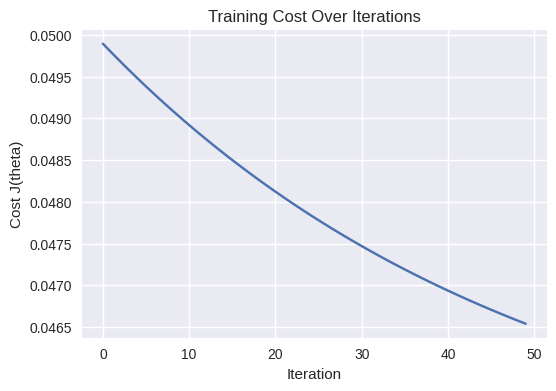


Learned parameters (theta):
                  bias: 0.000119
   recent_price_change: -0.041261
          trade_volume: 0.000309
 time_since_last_trade: -0.000965


In [90]:
# ===============================
# STEP 4: LINEAR REGRESSION FROM SCRATCH
# (Andrew Ng notation, clean & correct)
# ===============================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Prepare X and y
# -------------------------------

# X = features, y = target
X_features = X.values                      # shape: (m, 3)
y_vec = y.values.reshape(-1, 1)            # shape: (m, 1)

m, n = X_features.shape
print(f"m (samples): {m}, n (features): {n}")

# -------------------------------
# 2. Feature scaling (IMPORTANT)
# -------------------------------

mu = X_features.mean(axis=0)
sigma = X_features.std(axis=0) + 1e-8      # avoid divide by zero

X_norm = (X_features - mu) / sigma         # normalized features

# -------------------------------
# 3. Add bias term (x0 = 1)
# -------------------------------

X_mat = np.hstack([np.ones((m, 1)), X_norm])  # shape: (m, n+1)

print("X_mat shape:", X_mat.shape)
print("y shape:", y_vec.shape)

# -------------------------------
# 4. Initialize parameters theta
# -------------------------------

theta = np.zeros((n + 1, 1))                # shape: (n+1, 1)

# -------------------------------
# 5. Hypothesis function
# h_theta(x) = X * theta
# -------------------------------

def hypothesis(X, theta):
    return X @ theta

# -------------------------------
# 6. Cost function J(theta)
# J = (1 / 2m) * sum((Xθ - y)^2)
# -------------------------------

def compute_cost(X, y, theta):
    errors = hypothesis(X, theta) - y
    return (1 / (2 * len(y))) * np.sum(errors ** 2)

# -------------------------------
# 7. Gradient descent step
# theta := theta - alpha * (1/m) * X^T (Xθ - y)
# -------------------------------

def gradient_descent_step(X, y, theta, alpha):
    gradients = (1 / len(y)) * (X.T @ (hypothesis(X, theta) - y))
    return theta - alpha * gradients

# -------------------------------
# 8. Training loop
# -------------------------------

alpha = 0.01
num_iters = 50

J_history = []

for i in range(num_iters):
    theta = gradient_descent_step(X_mat, y_vec, theta, alpha)
    cost = compute_cost(X_mat, y_vec, theta)
    J_history.append(cost)

    if i % 10 == 0:
        print(f"Iteration {i}, J(theta) = {cost:.6f}")

# -------------------------------
# 9. Plot cost vs iterations
# -------------------------------

plt.figure(figsize=(6,4))
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Training Cost Over Iterations")
plt.grid(True)
plt.show()

# -------------------------------
# 10. Print learned parameters
# -------------------------------

feature_names = ["bias", "recent_price_change", "trade_volume", "time_since_last_trade"]

print("\nLearned parameters (theta):")
for name, value in zip(feature_names, theta.flatten()):
    print(f"{name:>22}: {value:.6f}")



In [75]:
# -------------------------------
# STEP 5.1: Time-based split
# -------------------------------

split_ratio = 0.8
split_index = int(len(X_mat) * split_ratio)

X_train = X_mat[:split_index]
y_train = y_vec[:split_index]

X_test = X_mat[split_index:]
y_test = y_vec[split_index:]

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])


Train samples: 1984857
Test samples : 496215


In [76]:
# -------------------------------
# STEP 5.2: Train on past data
# -------------------------------

theta = np.zeros((X_train.shape[1], 1))
alpha = 0.01
num_iters = 50

train_costs = []

for i in range(num_iters):
    theta = gradient_descent_step(X_train, y_train, theta, alpha)
    cost = compute_cost(X_train, y_train, theta)
    train_costs.append(cost)

    if i % 10 == 0:
        print(f"Iteration {i}, Train J(theta): {cost:.6f}")


Iteration 0, Train J(theta): 0.049284
Iteration 10, Train J(theta): 0.048363
Iteration 20, Train J(theta): 0.047607
Iteration 30, Train J(theta): 0.046987
Iteration 40, Train J(theta): 0.046479


In [77]:
# -------------------------------
# STEP 5.3: Test evaluation
# -------------------------------

y_test_pred = hypothesis(X_test, theta)

test_cost = compute_cost(X_test, y_test, theta)
print(f"\nTest Cost J(theta): {test_cost:.6f}")



Test Cost J(theta): 0.048637


In [78]:
# -------------------------------
# STEP 5.4: Inspect one prediction
# -------------------------------

i = 0  # first unseen example

true_value = y_test[i][0]
pred_value = y_test_pred[i][0]

print("True future price change :", true_value)
print("Predicted price change   :", pred_value)
print("Prediction error         :", pred_value - true_value)


True future price change : 0.6000000000021828
Predicted price change   : 0.07990623326115678
Prediction error         : -0.520093766741026


In [79]:
# -------------------------------
# STEP 5.5: Direction accuracy
# -------------------------------

true_direction = np.sign(y_test)
pred_direction = np.sign(y_test_pred)

direction_accuracy = np.mean(true_direction == pred_direction)

print(f"Directional accuracy: {direction_accuracy * 100:.2f}%")


Directional accuracy: 53.92%


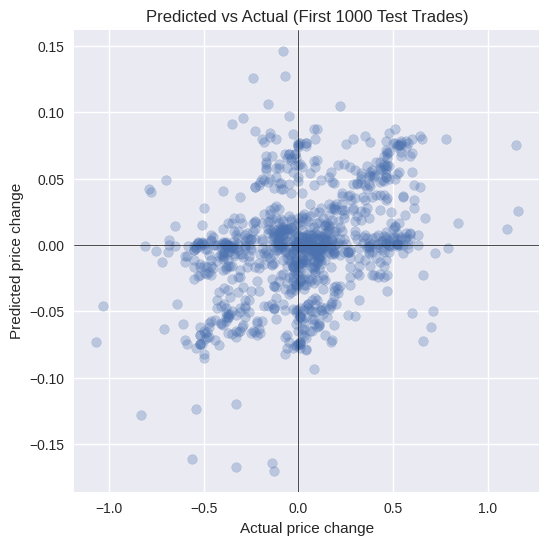

In [80]:
# -------------------------------
# STEP 5.6: Predicted vs Actual
# -------------------------------

plt.figure(figsize=(6,6))
plt.scatter(y_test[:1000], y_test_pred[:1000], alpha=0.3)
plt.xlabel("Actual price change")
plt.ylabel("Predicted price change")
plt.title("Predicted vs Actual (First 1000 Test Trades)")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True)
plt.show()


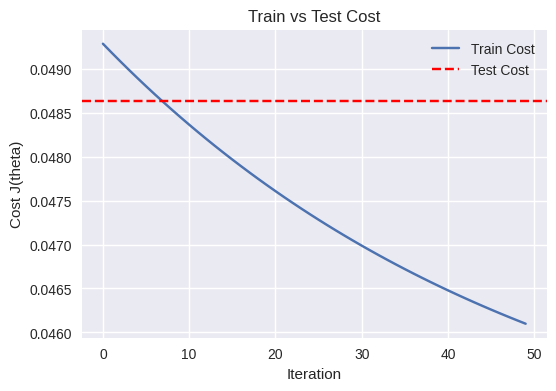

In [81]:
# -------------------------------
# STEP 5.7: Cost comparison
# -------------------------------

plt.figure(figsize=(6,4))
plt.plot(train_costs, label="Train Cost")
plt.axhline(test_cost, color="red", linestyle="--", label="Test Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Train vs Test Cost")
plt.legend()
plt.grid(True)
plt.show()


Training Batch Gradient Descent...

Training Mini-Batch Gradient Descent...
Epoch 0, Mini-batch Cost: 0.044153
Epoch 1, Mini-batch Cost: 0.044152
Epoch 2, Mini-batch Cost: 0.044154
Epoch 3, Mini-batch Cost: 0.044153
Epoch 4, Mini-batch Cost: 0.044154


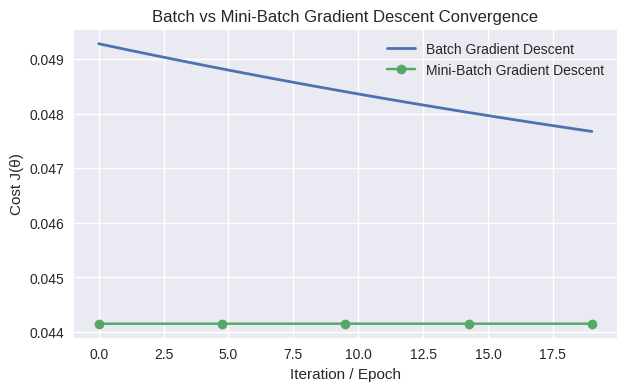

Test Cost (Batch GD):       0.050489046172369274
Test Cost (Mini-Batch GD):  0.04612071640614793


In [82]:
# ============================================================
# STEP 6: MINI-BATCH GRADIENT DESCENT vs BATCH GD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Reuse hypothesis and cost functions from previous steps
# ------------------------------------------------------------

def hypothesis(X, theta):
    return X @ theta

def compute_cost(X, y, theta):
    m = len(y)
    errors = hypothesis(X, theta) - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

# ------------------------------------------------------------
# Batch Gradient Descent (for comparison)
# ------------------------------------------------------------

def batch_gradient_descent(X, y, alpha=0.01, iterations=20):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []

    for i in range(iterations):
        gradients = (1 / len(y)) * (X.T @ (hypothesis(X, theta) - y))
        theta = theta - alpha * gradients
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

# ------------------------------------------------------------
# Mini-Batch Gradient Descent
# ------------------------------------------------------------

def mini_batch_gradient_descent(
    X, y, alpha=0.01, batch_size=1024, epochs=5
):
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradients = (1 / len(y_batch)) * (
                X_batch.T @ (hypothesis(X_batch, theta) - y_batch)
            )
            theta = theta - alpha * gradients

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        print(f"Epoch {epoch}, Mini-batch Cost: {cost:.6f}")

    return theta, cost_history

# ------------------------------------------------------------
# Train both models on TRAINING DATA ONLY
# ------------------------------------------------------------

print("Training Batch Gradient Descent...")
theta_batch, batch_costs = batch_gradient_descent(
    X_train, y_train, alpha=0.01, iterations=20
)

print("\nTraining Mini-Batch Gradient Descent...")
theta_minibatch, minibatch_costs = mini_batch_gradient_descent(
    X_train, y_train, alpha=0.01, batch_size=1024, epochs=5
)

# ------------------------------------------------------------
# Plot: Batch vs Mini-Batch Convergence
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(batch_costs, label="Batch Gradient Descent", linewidth=2)
plt.plot(
    np.linspace(0, len(batch_costs) - 1, len(minibatch_costs)),
    minibatch_costs,
    marker="o",
    label="Mini-Batch Gradient Descent",
)
plt.xlabel("Iteration / Epoch")
plt.ylabel("Cost J(θ)")
plt.title("Batch vs Mini-Batch Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Evaluate both models on TEST (future) data
# ------------------------------------------------------------

batch_test_cost = compute_cost(X_test, y_test, theta_batch)
minibatch_test_cost = compute_cost(X_test, y_test, theta_minibatch)

print("Test Cost (Batch GD):      ", batch_test_cost)
print("Test Cost (Mini-Batch GD): ", minibatch_test_cost)


Baseline MSE (predict 0):  0.10492626925829462
Model MSE (mini-batch):    0.09224143281229587
Baseline Directional Accuracy: 3.71%
Model Directional Accuracy:    53.92%


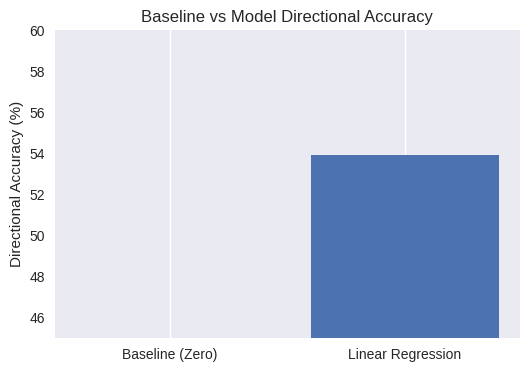

In [83]:
# ============================================================
# STEP 7: BASELINE COMPARISON (ZERO-PREDICTION MODEL)
# ============================================================
# Goal:
# To verify that our trained linear regression model is actually
# better than a naive baseline that assumes NO short-term edge.
#
# Baseline definition:
# Always predict 0 price change (i.e., no directional signal).
# This corresponds to assuming markets are completely random
# at this short horizon.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Generate baseline predictions
# ------------------------------------------------------------
# Baseline predicts zero price change for every test example

y_test_baseline = np.zeros_like(y_test)

# ------------------------------------------------------------
# 2. Compute MSE for baseline and model
# ------------------------------------------------------------
# MSE tells us how far predictions are from true values on average

baseline_mse = np.mean((y_test - y_test_baseline) ** 2)

model_predictions = hypothesis(X_test, theta_minibatch)
model_mse = np.mean((y_test - model_predictions) ** 2)

print("Baseline MSE (predict 0): ", baseline_mse)
print("Model MSE (mini-batch):   ", model_mse)

# ------------------------------------------------------------
# 3. Compute directional accuracy
# ------------------------------------------------------------
# Directional accuracy checks whether the model correctly
# predicts the SIGN (up/down) of future price movement.
# This is more relevant than magnitude in short-horizon finance.

true_direction = np.sign(y_test)
baseline_direction = np.sign(y_test_baseline)
model_direction = np.sign(model_predictions)

baseline_directional_accuracy = np.mean(baseline_direction == true_direction)
model_directional_accuracy = np.mean(model_direction == true_direction)

print(f"Baseline Directional Accuracy: {baseline_directional_accuracy * 100:.2f}%")
print(f"Model Directional Accuracy:    {model_directional_accuracy * 100:.2f}%")

# ------------------------------------------------------------
# 4. Visualization: Baseline vs Model comparison
# ------------------------------------------------------------
# This bar chart clearly shows whether the model adds value
# compared to doing nothing.

labels = ["Baseline (Zero)", "Linear Regression"]
directional_accuracies = [
    baseline_directional_accuracy * 100,
    model_directional_accuracy * 100
]

plt.figure(figsize=(6, 4))
plt.bar(labels, directional_accuracies)
plt.ylabel("Directional Accuracy (%)")
plt.title("Baseline vs Model Directional Accuracy")
plt.ylim(45, 60)
plt.grid(axis="y")
plt.show()


Horizon 5 trades → Directional Accuracy: 53.22%
Horizon 10 trades → Directional Accuracy: 53.94%
Horizon 15 trades → Directional Accuracy: 54.16%
Horizon 20 trades → Directional Accuracy: 54.39%
Horizon 25 trades → Directional Accuracy: 54.64%
Horizon 30 trades → Directional Accuracy: 54.64%
Horizon 35 trades → Directional Accuracy: 54.83%
Horizon 40 trades → Directional Accuracy: 54.93%


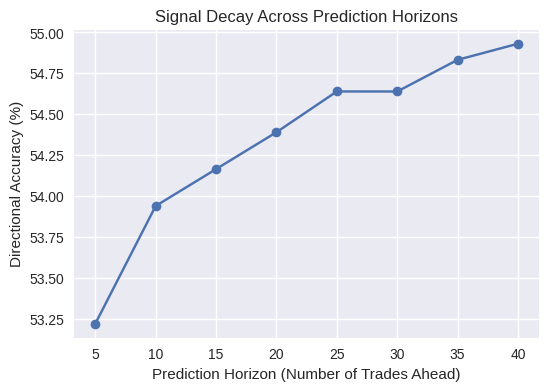

In [86]:
# ============================================================
# STEP 8: HORIZON COMPARISON (SIGNAL DECAY ANALYSIS)
# ============================================================
# Goal:
# To study how the predictive signal behaves as we try to
# predict further into the future.
#
# In quant finance, signals usually decay as the horizon
# increases. A good short-horizon model should perform best
# at small horizons and gradually lose power as horizon grows.
#
# We test the same model pipeline for:
#   - 5 trades ahead
#   - 10 trades ahead (current setup)
#   - 20 trades ahead
#
# We compare directional accuracy across horizons.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def run_pipeline_for_horizon(horizon):
    """
    Rebuilds the dataset for a given horizon, retrains the model
    using mini-batch gradient descent, and evaluates directional
    accuracy on unseen future data.
    """

    # ----------------------------
    # 1. Define new target variable
    # ----------------------------
    # Future price after `horizon` trades
    df_temp = df.copy()
    df_temp["future_price"] = df_temp["price"].shift(-horizon)
    df_temp["price_change"] = df_temp["future_price"] - df_temp["price"]

    # ----------------------------
    # 2. Feature engineering
    # ----------------------------
    df_temp["recent_price_change"] = df_temp["price"] - df_temp["price"].shift(5)
    df_temp["trade_volume"] = df_temp["volume"]
    df_temp["time_since_last_trade"] = df_temp["time_diff_ms"]

    df_temp = df_temp.dropna().reset_index(drop=True)

    X_features = df_temp[[
        "recent_price_change",
        "trade_volume",
        "time_since_last_trade"
    ]].values

    y_target = df_temp["price_change"].values.reshape(-1, 1)

    # ----------------------------
    # 3. Feature scaling
    # ----------------------------
    mu = X_features.mean(axis=0)
    sigma = X_features.std(axis=0) + 1e-8
    X_scaled = (X_features - mu) / sigma

    # Add bias term
    X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

    # ----------------------------
    # 4. Time-based train/test split
    # ----------------------------
    split_idx = int(0.8 * len(X_scaled))
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_target[:split_idx], y_target[split_idx:]

    # ----------------------------
    # 5. Train using mini-batch GD
    # ----------------------------
    theta = np.zeros((X_train.shape[1], 1))
    alpha = 0.01
    batch_size = 1024
    epochs = 5

    for _ in range(epochs):
        indices = np.random.permutation(len(y_train))
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for i in range(0, len(y_train), batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradients = (1 / len(y_batch)) * (
                X_batch.T @ (X_batch @ theta - y_batch)
            )
            theta -= alpha * gradients

    # ----------------------------
    # 6. Evaluate directional accuracy
    # ----------------------------
    predictions = X_test @ theta
    directional_accuracy = np.mean(
        np.sign(predictions) == np.sign(y_test)
    )

    return directional_accuracy

# ------------------------------------------------------------
# Run experiment for multiple horizons
# ------------------------------------------------------------

horizons = [5, 10, 15, 20, 25, 30, 35, 40]
directional_accuracies = []

for h in horizons:
    acc = run_pipeline_for_horizon(h)
    directional_accuracies.append(acc)
    print(f"Horizon {h} trades → Directional Accuracy: {acc * 100:.2f}%")

# ------------------------------------------------------------
# Visualization: Horizon vs Directional Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.plot(horizons, np.array(directional_accuracies) * 100, marker="o")
plt.xlabel("Prediction Horizon (Number of Trades Ahead)")
plt.ylabel("Directional Accuracy (%)")
plt.title("Signal Decay Across Prediction Horizons")
plt.grid(True)
plt.show()
